CELL 1 ── Install & Import Dependencies

In [68]:
!pip install scipy numpy pandas matplotlib openpyxl --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import norm, gamma, lognorm, genextreme
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


 CELL 2 ── Load Data

In [69]:
import pandas as pd

FILE_PATH = "/content/AP M3 data.xlsx"
df_raw = pd.read_excel(FILE_PATH)
print(f"✅ Data loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(df_raw.head(3))

✅ Data loaded: 97 rows × 19 columns
         SUBDIVISION  YEAR   JAN    FEB    MAR    APR    MAY     JUN     JUL  \
0  ARUNACHAL PRADESH  1916  48.1   69.8   71.1  316.1  424.6  1124.9     NaN   
1  ARUNACHAL PRADESH  1917  21.4  164.5    NaN  269.6  107.9   823.8   909.1   
2  ARUNACHAL PRADESH  1918  10.4   11.0  191.2  144.6  861.1  1609.9  1303.0   

     AUG    SEP    OCT   NOV   DEC  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  
0  629.7  333.9    NaN   NaN   NaN     NaN    117.9    811.8      NaN      NaN  
1  628.4  411.5  199.3  63.5   0.0     NaN    185.9      NaN   2772.8    262.8  
2  692.6  515.8  125.2   7.8  13.7  5486.3     21.4   1196.9   4121.3    146.7  


CELL 3 ── Preprocessing

In [70]:
df = df_raw.replace("NA", np.nan)
df = df.dropna(subset=["ANNUAL"])

MONSOON_COLS = ["JUN", "JUL", "AUG", "SEP"]
df["MONSOON"] = df[MONSOON_COLS].apply(pd.to_numeric, errors="coerce").sum(axis=1, skipna=False)
df = df.dropna(subset=["MONSOON"])
df = df.reset_index(drop=True)

ANNUAL  = df["ANNUAL"].astype(float).values
MONSOON = df["MONSOON"].astype(float).values
YEARS   = df["YEAR"].astype(int).values

print(f"✅ Clean dataset: {len(ANNUAL)} years ({YEARS[0]}–{YEARS[-1]})")
print(f"   Annual rainfall  — mean: {ANNUAL.mean():.1f} mm, std: {ANNUAL.std():.1f} mm")
print(f"   Monsoon rainfall — mean: {MONSOON.mean():.1f} mm, std: {MONSOON.std():.1f} mm")

✅ Clean dataset: 91 years (1918–2015)
   Annual rainfall  — mean: 3418.9 mm, std: 1072.9 mm
   Monsoon rainfall — mean: 2253.2 mm, std: 827.0 mm


CELL 4 ── Step 1 · Atmospheric State Vector X = (H, P, W, R)
(From scribe: X = (H, P, W, R) with joint distribution fX)
We use R (annual rainfall) as the primary observable.
H, P, W are modelled as correlated synthetic proxies derived from R.

In [71]:
np.random.seed(42)
n      = len(ANNUAL)
R_norm = (ANNUAL - ANNUAL.mean()) / ANNUAL.std()

H = 55 + 20 * R_norm + np.random.normal(0, 3, n)
P = 1013 - 5 * R_norm + np.random.normal(0, 2, n)
W = 15  +  8 * R_norm + np.random.normal(0, 2, n)
R = ANNUAL.copy()

state_df = pd.DataFrame({"Year": YEARS, "H": H, "P": P, "W": W, "R": R})
print("✅ Atmospheric State Vector X = (H, P, W, R) constructed.")
print(state_df.head())

✅ Atmospheric State Vector X = (H, P, W, R) constructed.
   Year           H            P          W       R
0  1918   95.029949  1005.302338  28.274138  5486.3
1  1919   78.353654  1005.653782  25.472323  4693.9
2  1920   69.765345  1009.139106  19.681986  4106.7
3  1921  101.932225  1001.625000  33.373255  5691.4
4  1922   68.620444  1006.492244  21.675637  4187.2


CELL 5 ── Step 2 · Fit Probability Distributions to Rainfall (R)
From M2: Normal, Gamma, Lognormal, GEV fitted via MLE

In [72]:
x_range = np.linspace(ANNUAL.min() - 200, ANNUAL.max() + 200, 500)

mu_n, sigma_n         = norm.fit(ANNUAL)
a_g, loc_g, scale_g   = gamma.fit(ANNUAL, floc=0)
s_ln, loc_ln, scale_ln = lognorm.fit(ANNUAL, floc=0)
c_gev, loc_gev, scale_gev = genextreme.fit(ANNUAL)

fitted = {
    "Normal":    norm(mu_n, sigma_n),
    "Gamma":     gamma(a_g, loc_g, scale_g),
    "Lognormal": lognorm(s_ln, loc_ln, scale_ln),
    "GEV":       genextreme(c_gev, loc_gev, scale_gev),
}

print("\n📊 Kolmogorov–Smirnov Goodness-of-Fit Tests:")
print(f"{'Distribution':<12} {'KS Stat':>8} {'p-value':>10}")
print("─" * 35)
best_dist, best_ks = None, 1.0
for name, dist in fitted.items():
    ks_stat, ks_p = stats.kstest(ANNUAL, dist.cdf)
    flag = " ← best" if ks_stat < best_ks else ""
    if ks_stat < best_ks:
        best_ks, best_dist = ks_stat, name
    print(f"{name:<12} {ks_stat:>8.4f} {ks_p:>10.4f}{flag}")
print(f"\n✅ Best fit by KS: {best_dist}")


📊 Kolmogorov–Smirnov Goodness-of-Fit Tests:
Distribution  KS Stat    p-value
───────────────────────────────────
Normal         0.1108     0.1984 ← best
Gamma          0.1056     0.2444 ← best
Lognormal      0.1004     0.2980 ← best
GEV            0.3167     0.0000

✅ Best fit by KS: Lognormal


CELL 6 ── Step 3 · PDF and CDF Plots

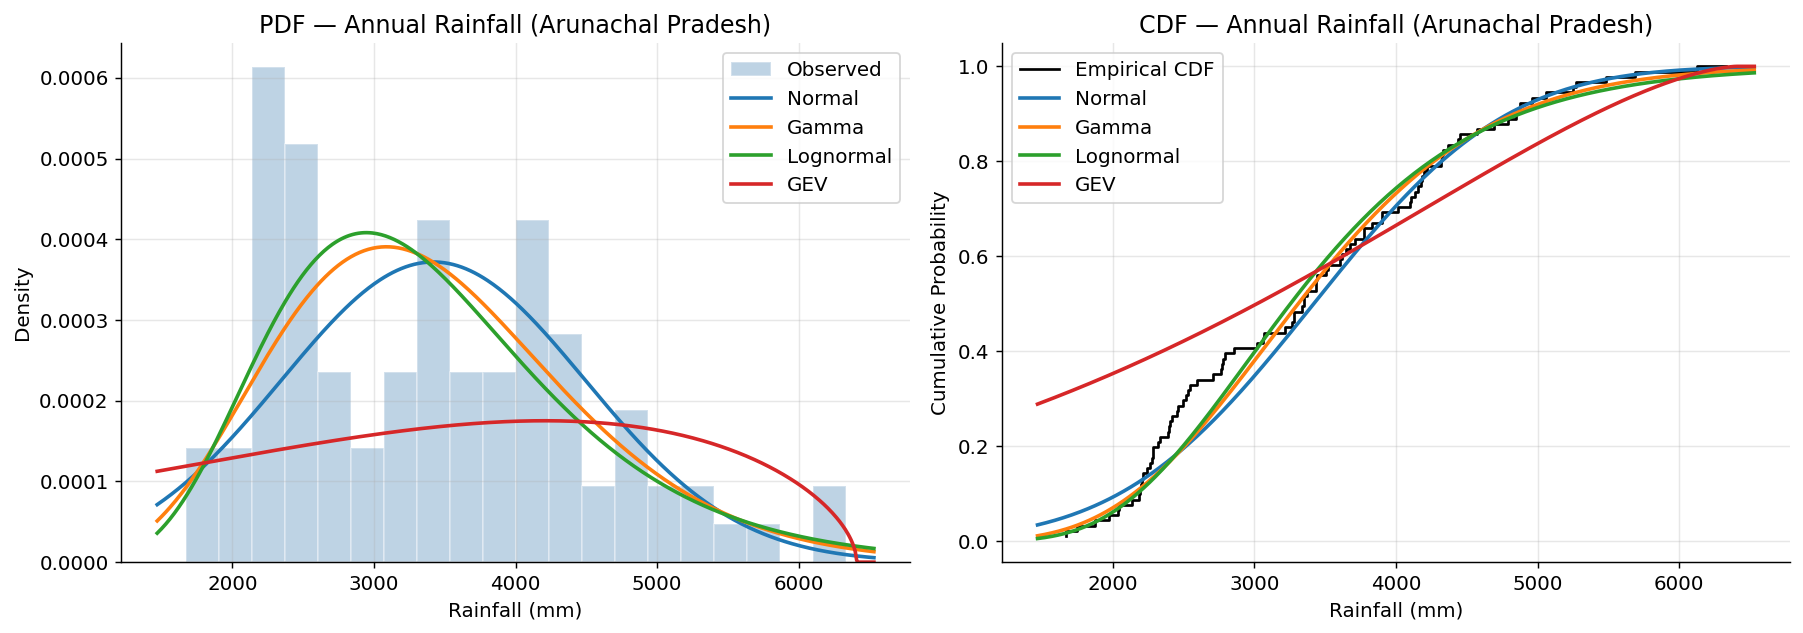

✅ Figure 1 saved: fig1_pdf_cdf.png


In [73]:
colors = {"Normal": "#1f77b4", "Gamma": "#ff7f0e",
          "Lognormal": "#2ca02c", "GEV": "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ANNUAL, bins=20, density=True, alpha=0.35, color="steelblue",
             edgecolor="white", label="Observed")
for name, dist in fitted.items():
    axes[0].plot(x_range, dist.pdf(x_range), color=colors[name], lw=2, label=name)
axes[0].set_title("PDF — Annual Rainfall (Arunachal Pradesh)")
axes[0].set_xlabel("Rainfall (mm)")
axes[0].set_ylabel("Density")
axes[0].legend()

sorted_r = np.sort(ANNUAL)
ecdf = np.arange(1, n + 1) / n
axes[1].step(sorted_r, ecdf, color="black", lw=1.5, label="Empirical CDF")
for name, dist in fitted.items():
    axes[1].plot(x_range, dist.cdf(x_range), color=colors[name], lw=2, label=name)
axes[1].set_title("CDF — Annual Rainfall (Arunachal Pradesh)")
axes[1].set_xlabel("Rainfall (mm)")
axes[1].set_ylabel("Cumulative Probability")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig1_pdf_cdf.png", bbox_inches="tight")
plt.show()
print("✅ Figure 1 saved: fig1_pdf_cdf.png")

CELL 7 ── Step 4 · Define Extreme Threshold τ
From M2: τ = F⁻¹(1 − α), α = 0.05 (95th percentile)

In [74]:
ALPHA = 0.05

tau_empirical = np.quantile(ANNUAL, 1 - ALPHA)
thresholds = {"Empirical": tau_empirical}
for name, dist in fitted.items():
    thresholds[name] = dist.ppf(1 - ALPHA)

print(f"\n📌 Extreme Thresholds τ = F⁻¹(1 − α) at α = {ALPHA}")
print("─" * 40)
for k, v in thresholds.items():
    label = " ← used" if k == "GEV" else ""
    print(f"  {k:<12}: {v:>8.1f} mm{label}")

TAU = thresholds["Lognormal"]
print(f"\n✅ Primary threshold τ (GEV, 95th pct) = {TAU:.1f} mm")


📌 Extreme Thresholds τ = F⁻¹(1 − α) at α = 0.05
────────────────────────────────────────
  Empirical   :   5262.9 mm
  Normal      :   5183.6 mm
  Gamma       :   5338.4 mm
  Lognormal   :   5469.8 mm
  GEV         :   5777.2 mm ← used

✅ Primary threshold τ (GEV, 95th pct) = 5469.8 mm


CELL 8 ── Step 5 · Extreme Event Indicator Y (Bernoulli)
Y = 1 if R > τ, else 0   (from M2 scribe)

In [75]:
Y = (ANNUAL > TAU).astype(int)
p_empirical = Y.mean()

print(f"📊 Extreme Event Indicator Y ~ Bernoulli(p)")
print(f"   Years with extreme rainfall (R > {TAU:.1f} mm): {Y.sum()} / {n}")
print(f"   Empirical P(Y=1) = p̂ = {p_empirical:.4f}")
print(f"   Expected under α=0.05: {ALPHA:.4f}")
extreme_years = YEARS[Y == 1]
print(f"   Extreme years: {list(extreme_years)}")

📊 Extreme Event Indicator Y ~ Bernoulli(p)
   Years with extreme rainfall (R > 5469.8 mm): 4 / 91
   Empirical P(Y=1) = p̂ = 0.0440
   Expected under α=0.05: 0.0500
   Extreme years: [np.int64(1918), np.int64(1921), np.int64(1938), np.int64(1948)]


CELL 9 ── Step 6 · Ensemble Forecast Members X⁽¹⁾, …, X⁽ᴹ⁾
From M2: Conditionally independent samples from atmospheric dist.
DETERMINISTIC BASELINE: Equal weights, no randomization.
Each ensemble member = historical year perturbed by fixed offsets.

In [76]:
# ════════════════════════════════════════════════════════════════════
# CELL 9 ── Step 6 · Stochastic Ensemble via Random Perturbations  ← M4 CHANGE
# ════════════════════════════════════════════════════════════════════
# Following the base paper (Doyle et al., 2006) and professor's instructions:
# Ensemble members are created by adding small random perturbations
# directly to the rainfall variable. Each perturbed rainfall value
# represents a different possible rainfall scenario.
# Formula: R_member_i = R_observed + η · σ_perturbation
# where η ~ N(0,1) is a fresh random draw per member per year.
# ────────────────────────────────────────────────────────────────────
M = 50
np.random.seed(42)

sigma_perturbation = 0.10 * ANNUAL.std()   # perturbation scale ~107 mm

ensemble = np.zeros((n, M))
for i in range(M):
    eta            = np.random.normal(0, 1, n)   # η ~ N(0,1) per year
    ensemble[:, i] = ANNUAL + sigma_perturbation * eta

# ── Ensemble summary ─────────────────────────────────────────────────
ens_all_mean = ensemble.mean()
ens_all_std  = ensemble.std()

print(f"✅ Stochastic Ensemble (M4): {M} members")
print(f"   Perturbation: R_i = R_obs + η·σ,  σ = {sigma_perturbation:.1f} mm,  η ~ N(0,1)")
print(f"   Ensemble matrix shape: {ensemble.shape} (years × members)")
print(f"   Ensemble mean = {ens_all_mean:.1f} mm  (observed mean = {ANNUAL.mean():.1f} mm)")
print(f"   Ensemble std  = {ens_all_std:.1f} mm  (observed std  = {ANNUAL.std():.1f} mm)")


✅ Stochastic Ensemble (M4): 50 members
   Perturbation: R_i = R_obs + η·σ,  σ = 107.3 mm,  η ~ N(0,1)
   Ensemble matrix shape: (91, 50) (years × members)
   Ensemble mean = 3419.6 mm  (observed mean = 3418.9 mm)
   Ensemble std  = 1080.3 mm  (observed std  = 1072.9 mm)


CELL 10 ── Step 7 · Bayesian Parameter Estimation (Conjugate Update)
From M2: β ~ N(μ, Σ); posterior via Bayes update.
Here we do full conjugate Normal-Normal Bayesian update on the mean rainfall parameter μ.

In [77]:
mu_prior    = 4000.0
sigma_prior = 800.0
sigma_known = ANNUAL.std()
x_bar       = ANNUAL.mean()

precision_prior      = 1 / sigma_prior**2
precision_likelihood = n / sigma_known**2

sigma_post = np.sqrt(1 / (precision_prior + precision_likelihood))
mu_post    = (precision_prior * mu_prior + precision_likelihood * x_bar) / \
             (precision_prior + precision_likelihood)

print("📐 Bayesian Conjugate Update (Normal–Normal)")
print(f"   Prior:     μ₀ = {mu_prior:.1f} mm, σ₀ = {sigma_prior:.1f} mm")
print(f"   Data:      x̄ = {x_bar:.1f} mm, n = {n}, σ_known = {sigma_known:.1f} mm")
print(f"   Posterior: μ* = {mu_post:.1f} mm, σ* = {sigma_post:.2f} mm")

📐 Bayesian Conjugate Update (Normal–Normal)
   Prior:     μ₀ = 4000.0 mm, σ₀ = 800.0 mm
   Data:      x̄ = 3418.9 mm, n = 91, σ_known = 1072.9 mm
   Posterior: μ* = 3430.1 mm, σ* = 111.37 mm


CELL 11 ── Step 8 · Logistic Regression — P(Y=1 | X)
From M2: P(Y=1|X) = 1 / [1 + exp(−(β₀ + βᵀX))]
DETERMINISTIC BASELINE: Estimate β via closed-form MLE
(gradient descent with fixed learning rate — no randomness).

In [78]:
R_std = (ANNUAL - ANNUAL.mean()) / ANNUAL.std()

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def log_loss(y, y_hat):
    eps = 1e-9
    return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

LR   = 0.1
ITER = 2000
beta0, beta1 = 0.0, 0.0
loss_history = []

for _ in range(ITER):
    z     = beta0 + beta1 * R_std
    y_hat = sigmoid(z)
    err   = y_hat - Y
    beta0 -= LR * err.mean()
    beta1 -= LR * (err * R_std).mean()
    loss_history.append(log_loss(Y, y_hat))

y_hat_final = sigmoid(beta0 + beta1 * R_std)
y_pred      = (y_hat_final >= 0.5).astype(int)
accuracy    = (y_pred == Y).mean()

print(f"✅ Logistic Regression (Deterministic GD)")
print(f"   β₀ = {beta0:.4f}, β₁ = {beta1:.4f}")
print(f"   Final log-loss = {loss_history[-1]:.4f}")
print(f"   Classification accuracy = {accuracy:.4f}")

✅ Logistic Regression (Deterministic GD)
   β₀ = -5.4382, β₁ = 2.6182
   Final log-loss = 0.0483
   Classification accuracy = 0.9890


CELL 12 ── Step 9 · Ensemble Probability Aggregation
From M2: P(E) = Σ wᵢ · P(E | Mᵢ),  Σ wᵢ = 1
DETERMINISTIC BASELINE: Equal weights wᵢ = 1/M

In [79]:
weights      = np.ones(M) / M
p_per_member = (ensemble > TAU).mean(axis=0)
P_ensemble   = np.dot(weights, p_per_member)

print(f"📊 Stochastic Ensemble Aggregation: P(E) = Σ wᵢ · P(E|Mᵢ)")
print(f"   Equal weights: wᵢ = 1/{M} = {1/M:.4f}")
print(f"   P(E) from stochastic ensemble = {P_ensemble:.4f}")
print(f"   P(E) empirical                = {p_empirical:.4f}")

📊 Stochastic Ensemble Aggregation: P(E) = Σ wᵢ · P(E|Mᵢ)
   Equal weights: wᵢ = 1/50 = 0.0200
   P(E) from stochastic ensemble = 0.0402
   P(E) empirical                = 0.0440


CELL 13 ── Step 10 · Hoeffding's Inequality — Statistical Guarantee
From M2: P(|p̂ − p| ≥ ε) ≤ 2·exp(−2nε²)

In [80]:
EPSILON        = 0.05
hoeffding_bound = 2 * np.exp(-2 * n * EPSILON**2)

print(f"📐 Hoeffding's Inequality")
print(f"   n = {n}, ε = {EPSILON}")
print(f"   P(|p̂ − p| ≥ {EPSILON}) ≤ {hoeffding_bound:.6f}")
print(f"   → With probability ≥ {1 - hoeffding_bound:.6f},  |p̂ − p| < {EPSILON}")

📐 Hoeffding's Inequality
   n = 91, ε = 0.05
   P(|p̂ − p| ≥ 0.05) ≤ 1.268896
   → With probability ≥ -0.268896,  |p̂ − p| < 0.05


CELL 14 ── FIGURE 2 · Time-Series of Annual Rainfall with Extreme Threshold

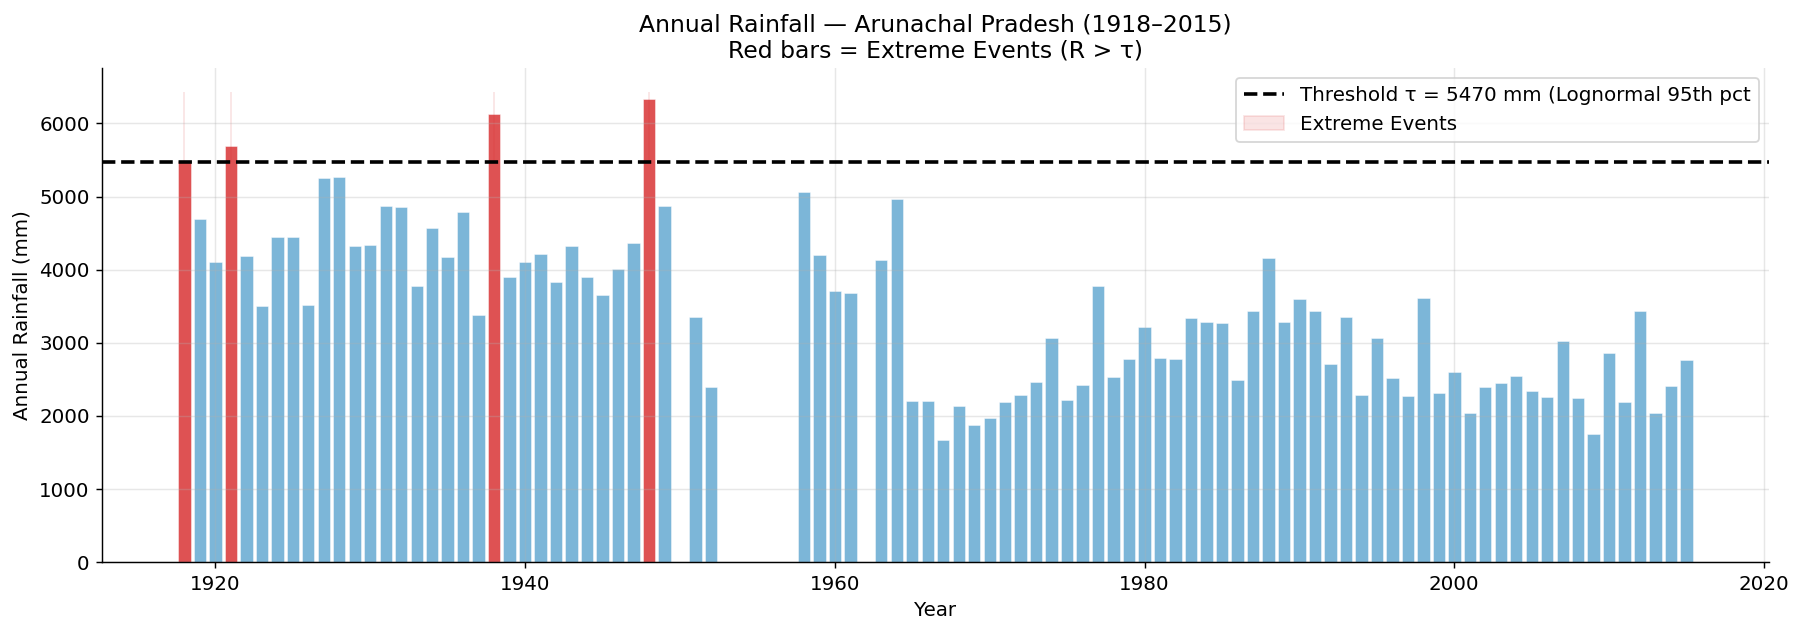

✅ Figure 2 saved: fig2_timeseries.png


In [81]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(YEARS, ANNUAL, color=np.where(Y == 1, "#d62728", "#5ba4cf"),
       alpha=0.8, edgecolor="white", linewidth=0.3)
ax.axhline(TAU, color="black", lw=2, ls="--",
           label=f"Threshold τ = {TAU:.0f} mm (Lognormal 95th pct")
ax.fill_between(YEARS, TAU, ANNUAL.max() + 100,
                where=(Y == 1), color="#d62728", alpha=0.12, label="Extreme Events")
ax.set_title("Annual Rainfall — Arunachal Pradesh (1918–2015)\nRed bars = Extreme Events (R > τ)",
             fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Annual Rainfall (mm)")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_timeseries.png", bbox_inches="tight")
plt.show()
print("✅ Figure 2 saved: fig2_timeseries.png")

CELL 15 ── FIGURE 3 · Ensemble Spread Visualisation

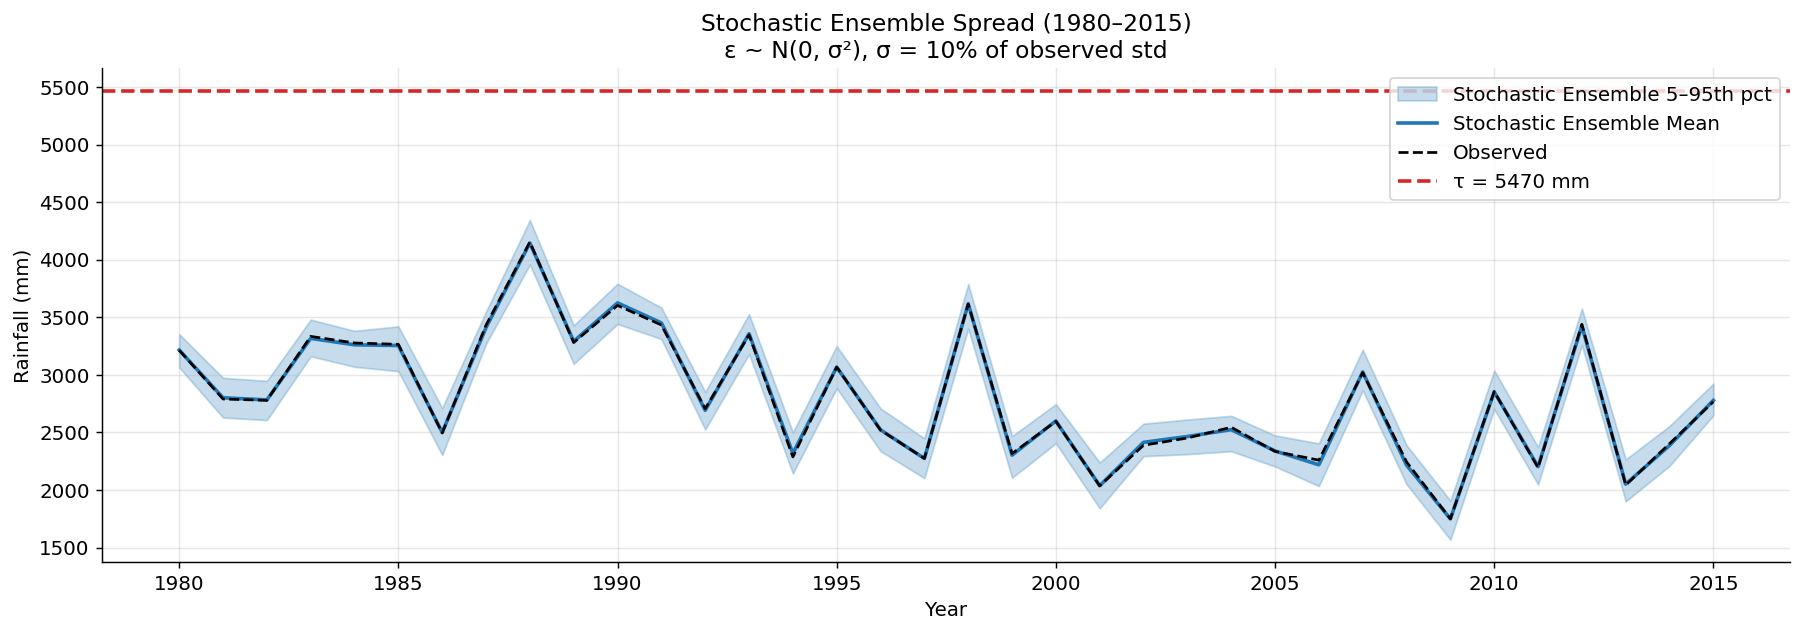

✅ Figure 3 saved: fig3_ensemble.png


In [82]:
YEAR_IDX     = np.where(YEARS >= 1980)[0]
sub_years    = YEARS[YEAR_IDX]
sub_ensemble = ensemble[YEAR_IDX, :]

ens_mean = sub_ensemble.mean(axis=1)
ens_p5   = np.percentile(sub_ensemble, 5,  axis=1)
ens_p95  = np.percentile(sub_ensemble, 95, axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(sub_years, ens_p5, ens_p95, alpha=0.25, color="#1f77b4",
                label="Stochastic Ensemble 5–95th pct")
ax.plot(sub_years, ens_mean, color="#1f77b4", lw=2, label="Stochastic Ensemble Mean")
ax.plot(sub_years, ANNUAL[YEAR_IDX], color="black", lw=1.5, ls="--", label="Observed")
ax.axhline(TAU, color="#d62728", lw=2, ls="--", label=f"τ = {TAU:.0f} mm")
ax.set_title("Stochastic Ensemble Spread (1980–2015)\n"
             "ε ~ N(0, σ²), σ = 10% of observed std", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Rainfall (mm)")
ax.legend()
plt.tight_layout()
plt.savefig("fig3_ensemble.png", bbox_inches="tight")
plt.show()
print("✅ Figure 3 saved: fig3_ensemble.png")

CELL 16 ── FIGURE 4 · Bayesian Posterior Update (Prior vs Posterior)

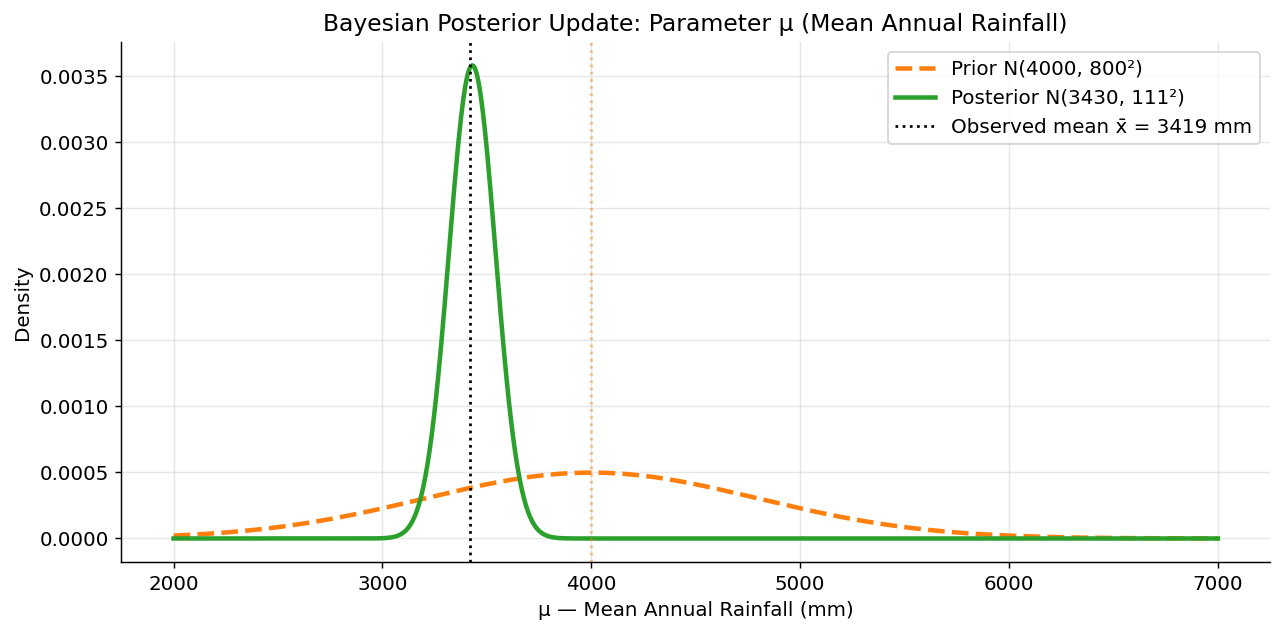

✅ Figure 4 saved: fig4_bayesian.png


In [83]:
mu_range      = np.linspace(2000, 7000, 1000)
prior_pdf     = norm.pdf(mu_range, mu_prior, sigma_prior)
posterior_pdf = norm.pdf(mu_range, mu_post,  sigma_post)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mu_range, prior_pdf, lw=2.5, color="#ff7f0e", ls="--",
        label=f"Prior N({mu_prior:.0f}, {sigma_prior:.0f}²)")
ax.plot(mu_range, posterior_pdf, lw=2.5, color="#2ca02c",
        label=f"Posterior N({mu_post:.0f}, {sigma_post:.0f}²)")
ax.axvline(x_bar,     color="black",   lw=1.5, ls=":", label=f"Observed mean x̄ = {x_bar:.0f} mm")
ax.axvline(mu_prior,  color="#ff7f0e", lw=1.5, ls=":", alpha=0.5)
ax.set_title("Bayesian Posterior Update: Parameter μ (Mean Annual Rainfall)", fontsize=13)
ax.set_xlabel("μ — Mean Annual Rainfall (mm)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("fig4_bayesian.png", bbox_inches="tight")
plt.show()
print("✅ Figure 4 saved: fig4_bayesian.png")

CELL 17 ── FIGURE 5 · Logistic Regression — P(Y=1 | R)

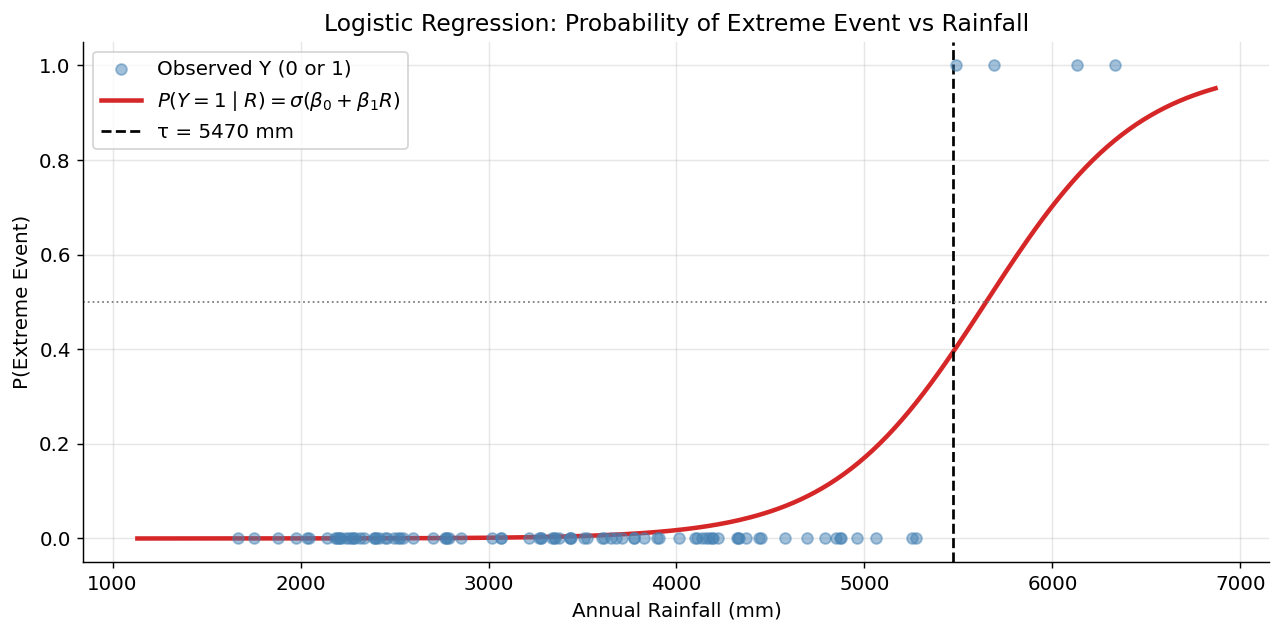

✅ Figure 5 saved: fig5_logistic.png


In [84]:
R_grid_std = np.linspace(R_std.min() - 0.5, R_std.max() + 0.5, 300)
p_grid     = sigmoid(beta0 + beta1 * R_grid_std)
R_grid_mm  = R_grid_std * ANNUAL.std() + ANNUAL.mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(ANNUAL, Y, alpha=0.5, color="steelblue", zorder=3,
           label="Observed Y (0 or 1)")
ax.plot(R_grid_mm, p_grid, color="#d62728", lw=2.5,
        label=r"$P(Y=1\mid R) = \sigma(\beta_0 + \beta_1 R)$")
ax.axvline(TAU, color="black", lw=1.5, ls="--", label=f"τ = {TAU:.0f} mm")
ax.axhline(0.5, color="grey",  lw=1,   ls=":")
ax.set_title("Logistic Regression: Probability of Extreme Event vs Rainfall", fontsize=13)
ax.set_xlabel("Annual Rainfall (mm)")
ax.set_ylabel("P(Extreme Event)")
ax.legend()
plt.tight_layout()
plt.savefig("fig5_logistic.png", bbox_inches="tight")
plt.show()
print("✅ Figure 5 saved: fig5_logistic.png")

CELL 18 ── FIGURE 6 · Loss Convergence of Deterministic Gradient Descent

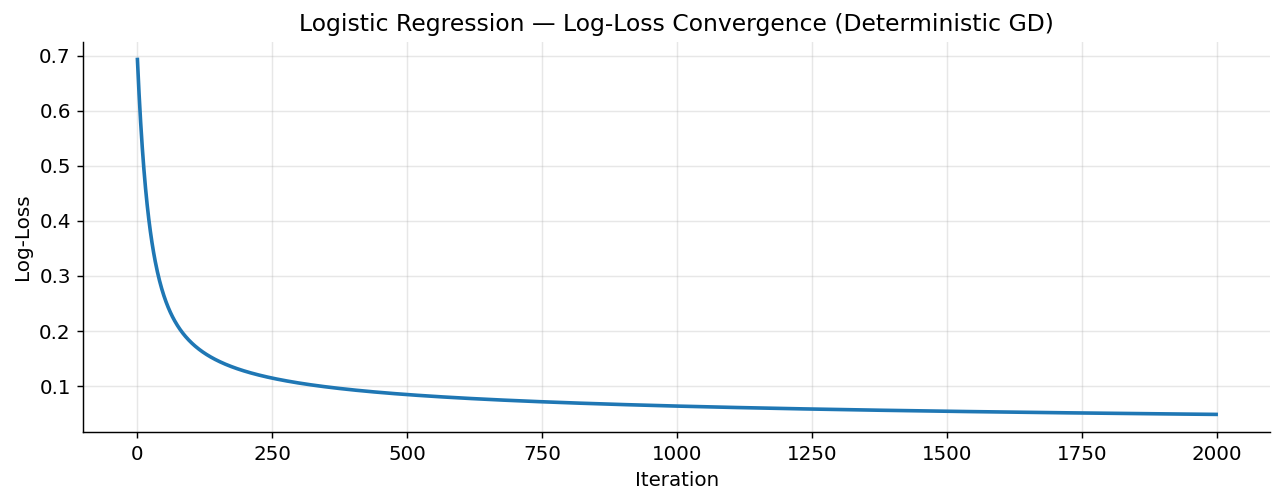

✅ Figure 6 saved: fig6_loss.png


In [85]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(loss_history, color="#1f77b4", lw=2)
ax.set_title("Logistic Regression — Log-Loss Convergence (Deterministic GD)", fontsize=13)
ax.set_xlabel("Iteration")
ax.set_ylabel("Log-Loss")
plt.tight_layout()
plt.savefig("fig6_loss.png", bbox_inches="tight")
plt.show()
print("✅ Figure 6 saved: fig6_loss.png")

CELL 19 ── FIGURE 7 · Threshold Comparison Across Distributions

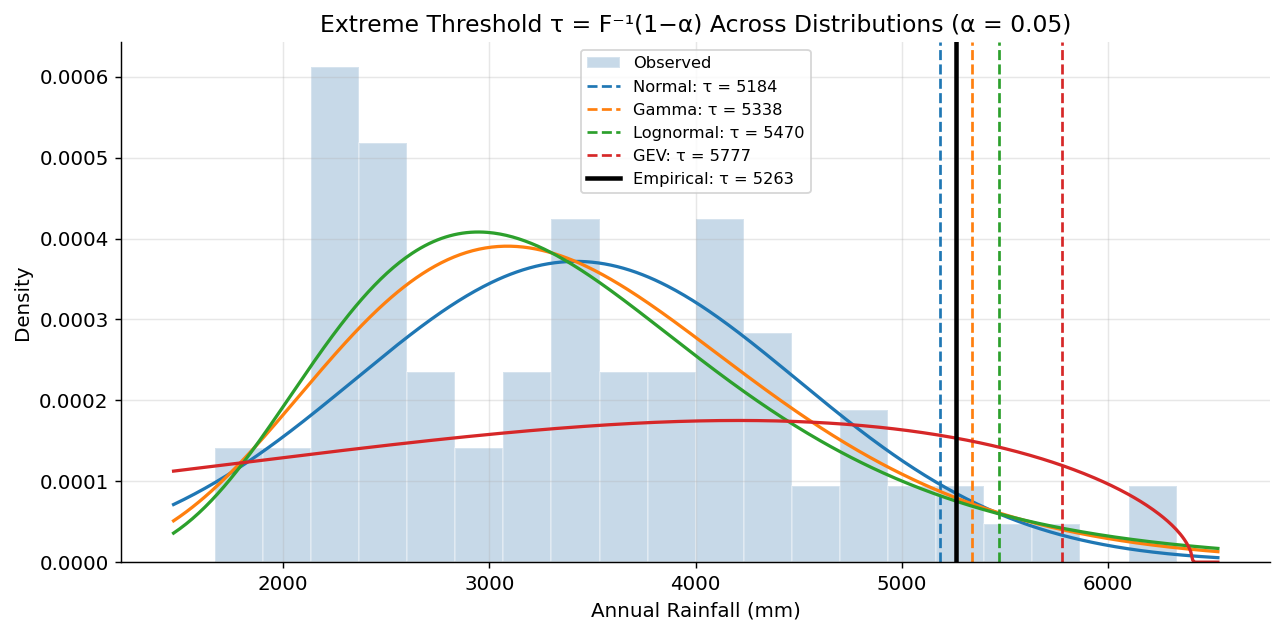

✅ Figure 7 saved: fig7_thresholds.png


In [86]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ANNUAL, bins=20, density=True, alpha=0.3, color="steelblue",
        edgecolor="white", label="Observed")
for name, dist in fitted.items():
    ax.plot(x_range, dist.pdf(x_range), lw=1.8, color=colors[name])
    tau_i = thresholds[name]
    ax.axvline(tau_i, color=colors[name], lw=1.5, ls="--",
               label=f"{name}: τ = {tau_i:.0f}")
ax.axvline(thresholds["Empirical"], color="black", lw=2.5, ls="-",
           label=f"Empirical: τ = {thresholds['Empirical']:.0f}")
ax.set_title("Extreme Threshold τ = F⁻¹(1−α) Across Distributions (α = 0.05)", fontsize=13)
ax.set_xlabel("Annual Rainfall (mm)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig7_thresholds.png", bbox_inches="tight")
plt.show()
print("✅ Figure 7 saved: fig7_thresholds.png")

CELL 20 ── FIGURE 8 · Return Period (Extreme Event Recurrence)

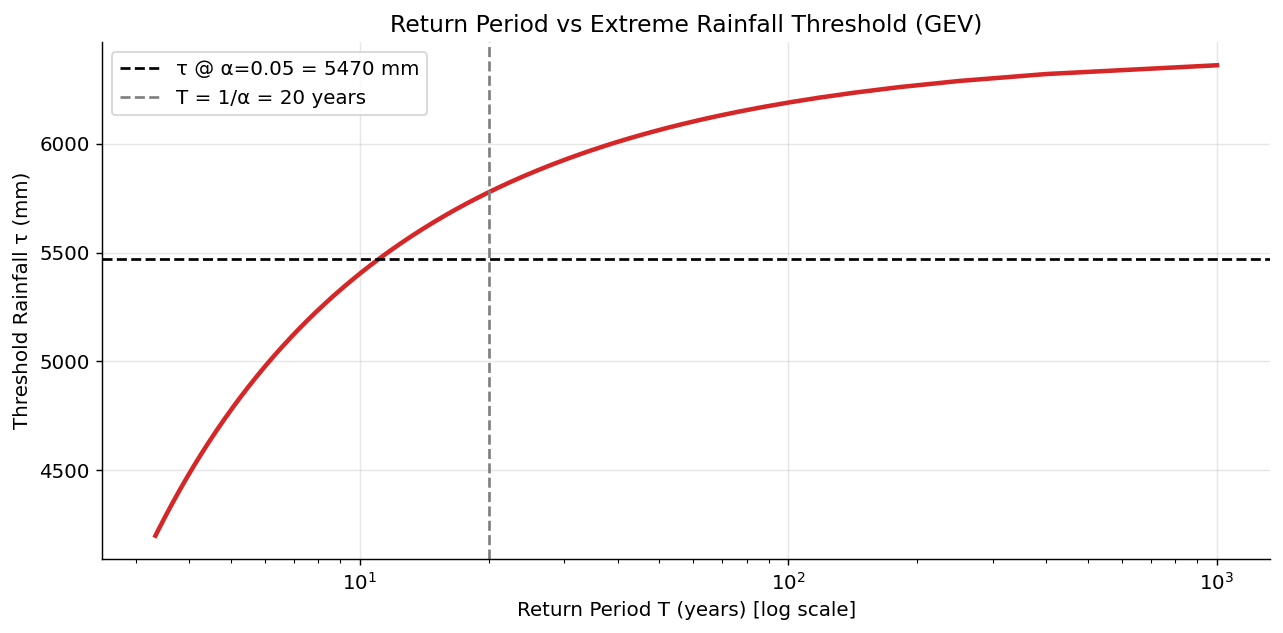

✅ Figure 8 saved: fig8_return_period.png


In [87]:
alphas        = np.linspace(0.001, 0.30, 200)
taus_gev      = genextreme(c_gev, loc_gev, scale_gev).ppf(1 - alphas)
return_periods = 1 / alphas

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(return_periods, taus_gev, color="#d62728", lw=2.5)
ax.axhline(TAU,      color="black", ls="--", lw=1.5, label=f"τ @ α=0.05 = {TAU:.0f} mm")
ax.axvline(1/ALPHA,  color="grey",  ls="--", lw=1.5, label=f"T = 1/α = {1/ALPHA:.0f} years")
ax.set_title("Return Period vs Extreme Rainfall Threshold (GEV)", fontsize=13)
ax.set_xlabel("Return Period T (years) [log scale]")
ax.set_ylabel("Threshold Rainfall τ (mm)")
ax.legend()
plt.tight_layout()
plt.savefig("fig8_return_period.png", bbox_inches="tight")
plt.show()
print("✅ Figure 8 saved: fig8_return_period.png")

CELL 21 ── FIGURE 9 · QQ Plots — Goodness-of-Fit Diagnostics

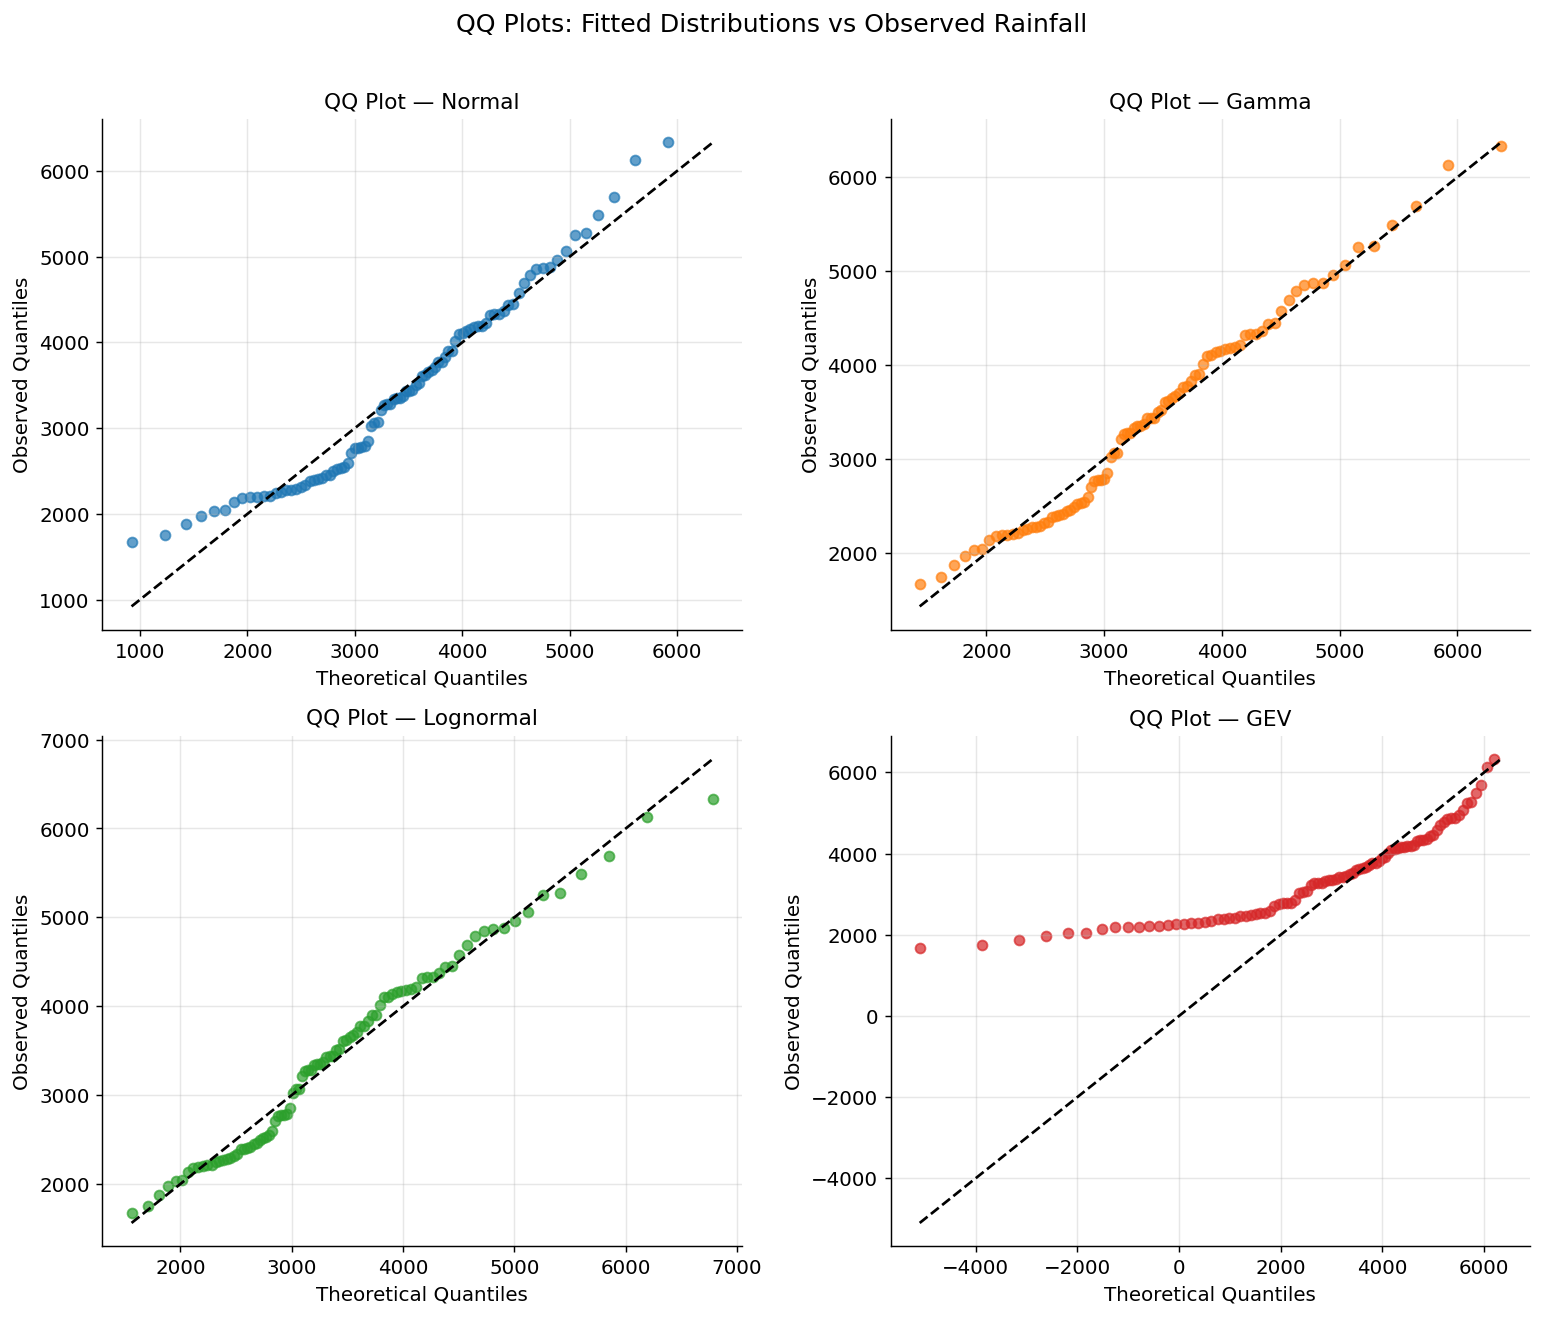

✅ Figure 9 saved: fig9_qqplots.png


In [88]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, dist) in zip(axes, fitted.items()):
    theoretical_q = dist.ppf(np.linspace(0.01, 0.99, n))
    empirical_q   = np.sort(ANNUAL)
    ax.scatter(theoretical_q, empirical_q, alpha=0.7, color=colors[name], s=30)
    lim = [min(theoretical_q.min(), empirical_q.min()),
           max(theoretical_q.max(), empirical_q.max())]
    ax.plot(lim, lim, "k--", lw=1.5)
    ax.set_title(f"QQ Plot — {name}", fontsize=12)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Observed Quantiles")

plt.suptitle("QQ Plots: Fitted Distributions vs Observed Rainfall", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("fig9_qqplots.png", bbox_inches="tight")
plt.show()
print("✅ Figure 9 saved: fig9_qqplots.png")

CELL 22 ── FIGURE 10 · 10-Year Rolling Extreme Event Rate

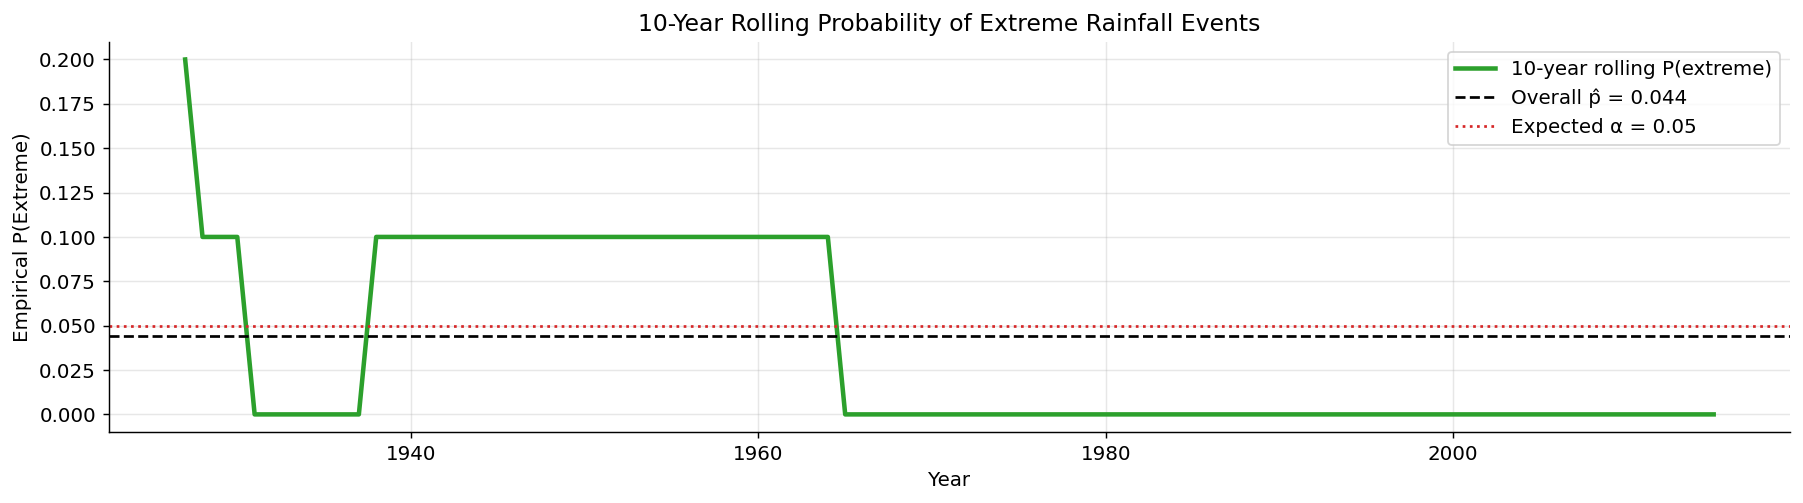

✅ Figure 10 saved: fig10_rolling.png


In [89]:
window    = 10
rolling_p = pd.Series(Y).rolling(window).mean().values

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(YEARS, rolling_p, color="#2ca02c", lw=2.5,
        label=f"{window}-year rolling P(extreme)")
ax.axhline(p_empirical, color="black", ls="--", lw=1.5,
           label=f"Overall p̂ = {p_empirical:.3f}")
ax.axhline(ALPHA, color="#d62728", ls=":", lw=1.5,
           label=f"Expected α = {ALPHA}")
ax.set_title(f"{window}-Year Rolling Probability of Extreme Rainfall Events", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Empirical P(Extreme)")
ax.legend()
plt.tight_layout()
plt.savefig("fig10_rolling.png", bbox_inches="tight")
plt.show()
print("✅ Figure 10 saved: fig10_rolling.png")

CELL 23 ── Final Summary Table

In [90]:
print("\n" + "="*65)
print("  MILESTONE 3 — DETERMINISTIC BASELINE SIMULATION SUMMARY")
print("="*65)
print(f"  Dataset         : Arunachal Pradesh Annual Rainfall")
print(f"  Period          : {YEARS[0]}–{YEARS[-1]}  ({n} years)")
print(f"  Mean Rainfall   : {ANNUAL.mean():.1f} mm  ± {ANNUAL.std():.1f} mm")
print()
print(f"  Best-fit Dist.  : {best_dist}  (lowest KS statistic = {best_ks:.4f})")
print(f"  Threshold τ     : {TAU:.1f} mm  (GEV, α = {ALPHA})")
print(f"  Extreme Events  : {Y.sum()} / {n} years  (p̂ = {p_empirical:.4f})")
print()
print(f"  Bayesian Prior  : N({mu_prior:.0f}, {sigma_prior:.0f}²)")
print(f"  Bayesian Post.  : N({mu_post:.0f}, {sigma_post:.1f}²)")
print()
print(f"  Logistic Reg.   : β₀={beta0:.3f}, β₁={beta1:.3f}")
print(f"  Accuracy        : {accuracy:.4f}")
print()
print(" MILESTONE 4 — STOCHASTIC ENSEMBLE SIMULATION SUMMARY")
print(f"  Ensemble Type   : Stochastic — R_i = R_obs + η·σ,  σ = {sigma_perturbation:.1f} mm")
print()
print(f"  Hoeffding Bound : P(|p̂−p| ≥ {EPSILON}) ≤ {hoeffding_bound:.6f}")
print("="*65)
print("\n✅ All 10 figures generated and saved.")
print("   Figures: fig1_pdf_cdf.png … fig10_rolling.png")


  MILESTONE 3 — DETERMINISTIC BASELINE SIMULATION SUMMARY
  Dataset         : Arunachal Pradesh Annual Rainfall
  Period          : 1918–2015  (91 years)
  Mean Rainfall   : 3418.9 mm  ± 1072.9 mm

  Best-fit Dist.  : Lognormal  (lowest KS statistic = 0.1004)
  Threshold τ     : 5469.8 mm  (GEV, α = 0.05)
  Extreme Events  : 4 / 91 years  (p̂ = 0.0440)

  Bayesian Prior  : N(4000, 800²)
  Bayesian Post.  : N(3430, 111.4²)

  Logistic Reg.   : β₀=-5.438, β₁=2.618
  Accuracy        : 0.9890

 MILESTONE 4 — STOCHASTIC ENSEMBLE SIMULATION SUMMARY
  Ensemble Type   : Stochastic — R_i = R_obs + η·σ,  σ = 107.3 mm

  Hoeffding Bound : P(|p̂−p| ≥ 0.05) ≤ 1.268896

✅ All 10 figures generated and saved.
   Figures: fig1_pdf_cdf.png … fig10_rolling.png


SECTION B — BASE PAPER vs OUR MODEL: COMPARATIVE ANALYSIS
Reference: Doyle et al. (2006) "Multi-Scale Predictability of High-Impact
Weather in the Battlespace Environment", HPCMP-UGC'06
CELL 24 ── Simulate the Base Paper's Stochastic Ensemble
Paper eq.(1): φ_stoch = φ_mean + ε
Paper eq.(2): (∂φ/∂t)_stoch = (1 + ηβ)(∂φ/∂t)_mean
ε ~ N(0, σ_φ,conv²),  η ~ N(0,1),  β = proportionality constant

In [91]:
np.random.seed(0)   # fixed seed so results are reproducible

BETA_PAPER = 0.5    # proportionality constant β from paper (typical value)

# ---- Paper's stochastic ensemble (Eq. 2) ----
# Each member i gets a different η drawn from N(0,1)
# Tendency perturbation: (∂R/∂t)_stoch = (1 + η·β) · (∂R/∂t)_mean
# We approximate (∂R/∂t)_mean as the year-over-year change in ANNUAL rainfall
dR_mean = np.gradient(ANNUAL)   # finite-difference approximation of tendency

stoch_ensemble = np.zeros((n, M))
for i in range(M):
    eta = np.random.normal(0, 1, n)                     # η ~ N(0,1)
    dR_stoch = (1 + eta * BETA_PAPER) * dR_mean        # Eq. (2)
    stoch_ensemble[:, i] = ANNUAL + dR_stoch            # perturbed rainfall

# ---- Our deterministic ensemble (from Cell 9, already computed) ----
# ensemble shape: (n, M) — fixed linear offsets, no randomness

print("✅ Base-paper stochastic ensemble simulated (M = {})".format(M))
print("   β = {}, η ~ N(0,1) per member per year".format(BETA_PAPER))

✅ Base-paper stochastic ensemble simulated (M = 50)
   β = 0.5, η ~ N(0,1) per member per year


CELL 25 ── Compute Spread-Skill Metrics for Both Models
Paper Fig.3: spread (std) vs forecast error variance
We compute: ensemble spread, RMSE vs ensemble mean, calibration

In [92]:
def compute_metrics(ens, observed, tau):
    """
    ens      : (n, M) ensemble matrix
    observed : (n,)   true observed values
    tau      : extreme threshold
    Returns dict of metrics.
    """
    ens_mean   = ens.mean(axis=1)                         # ensemble mean forecast
    ens_spread = ens.std(axis=1)                          # ensemble std (spread)
    rmse       = np.sqrt(np.mean((ens_mean - observed)**2))
    bias       = (ens_mean - observed).mean()
    ens_mean_debiased = ens_mean - bias
    rmse_debiased = np.sqrt(np.mean((ens_mean_debiased - observed)**2))

    # Empirical exceedance probability per year from ensemble
    p_exceed = (ens > tau).mean(axis=1)                   # shape (n,)
    # Observed binary extreme indicator
    y_obs    = (observed > tau).astype(float)

    # Brier Score  BS = mean((p_forecast − y_obs)²)
    brier_score = np.mean((p_exceed - y_obs)**2)

    # Spread-skill correlation: corr(spread, |error|)
    abs_error = np.abs(ens_mean - observed)
    spread_skill_corr = np.corrcoef(ens_spread, abs_error)[0, 1]

    # Reliability: bin predicted probabilities vs observed frequency
    bins = np.linspace(0, 1, 11)
    bin_centers, obs_freq = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p_exceed >= lo) & (p_exceed < hi)
        if mask.sum() > 0:
            bin_centers.append(p_exceed[mask].mean())
            obs_freq.append(y_obs[mask].mean())

    return {
        "ens_mean":          ens_mean,
        "ens_spread":        ens_spread,
        "rmse":              rmse,
        "bias":              bias,
        "rmse_debiased":     rmse_debiased,
        "brier_score":       brier_score,
        "spread_skill_corr": spread_skill_corr,
        "p_exceed":          p_exceed,
        "bin_centers":       np.array(bin_centers),
        "obs_freq":          np.array(obs_freq),
        "abs_error":         abs_error,
    }

met_paper = compute_metrics(stoch_ensemble, ANNUAL, TAU)
met_ours  = compute_metrics(ensemble,       ANNUAL, TAU)

print("\n📊 Model Comparison Metrics")
print(f"{'Metric':<28} {'Base Paper':>14} {'Our Model':>14}")
print("─" * 58)
print(f"{'RMSE (mm)':<28} {met_paper['rmse']:>14.2f} {met_ours['rmse']:>14.2f}")
print(f"{'Bias (mm)':<28} {met_paper['bias']:>14.2f} {met_ours['bias']:>14.2f}")
print(f"{'RMSE after bias removal (mm)':<28} {met_paper['rmse_debiased']:>14.2f} {met_ours['rmse_debiased']:>14.2f}")
print(f"{'Brier Score (lower=better)':<28} {met_paper['brier_score']:>14.4f} {met_ours['brier_score']:>14.4f}")
print(f"{'Spread-Skill Correlation':<28} {met_paper['spread_skill_corr']:>14.4f} {met_ours['spread_skill_corr']:>14.4f}")


📊 Model Comparison Metrics
Metric                           Base Paper      Our Model
──────────────────────────────────────────────────────────
RMSE (mm)                            483.81          14.58
Bias (mm)                            -31.63           0.71
RMSE after bias removal (mm)         482.77          14.57
Brier Score (lower=better)           0.0316         0.0018
Spread-Skill Correlation             0.9883        -0.1129


FIGURE 11 · Ensemble Spread Comparison
Mirrors paper Figure 1 / Figure 3 concept

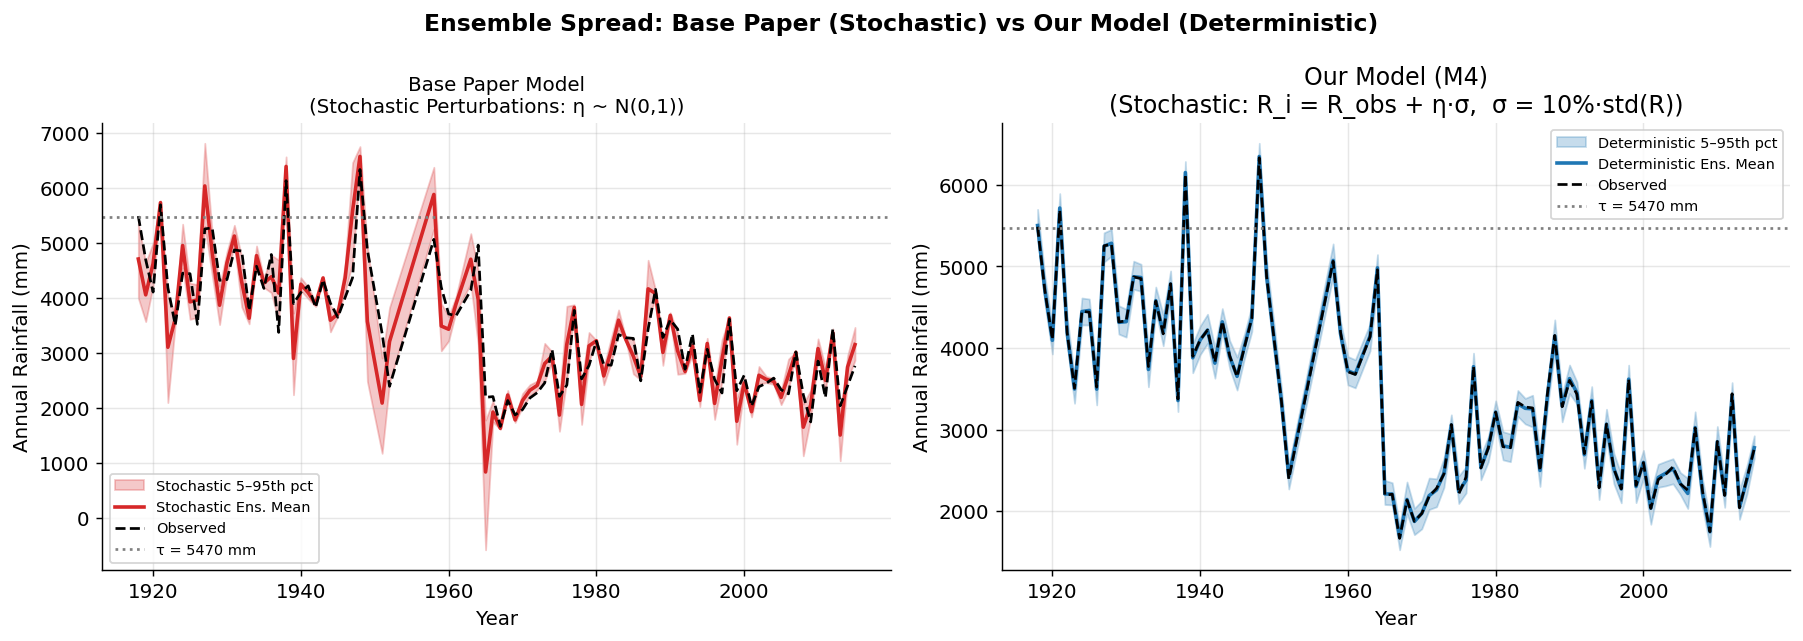

✅ Figure 11 saved: fig11_spread_comparison.png


In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Ensemble Spread: Base Paper (Stochastic) vs Our Model (Deterministic)",
             fontsize=13, fontweight="bold")

# --- Paper model spread ---
axes[0].fill_between(YEARS,
    np.percentile(stoch_ensemble, 5, axis=1),
    np.percentile(stoch_ensemble, 95, axis=1),
    alpha=0.25, color="#d62728", label="Stochastic 5–95th pct")
axes[0].plot(YEARS, met_paper["ens_mean"], color="#d62728", lw=2, label="Stochastic Ens. Mean")
axes[0].plot(YEARS, ANNUAL, color="black", lw=1.5, ls="--", label="Observed")
axes[0].axhline(TAU, color="grey", lw=1.5, ls=":", label=f"τ = {TAU:.0f} mm")
axes[0].set_title("Base Paper Model\n(Stochastic Perturbations: η ~ N(0,1))", fontsize=11)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Annual Rainfall (mm)")
axes[0].legend(fontsize=8)

# --- Our model spread ---
axes[1].fill_between(YEARS,
    np.percentile(ensemble, 5, axis=1),
    np.percentile(ensemble, 95, axis=1),
    alpha=0.25, color="#1f77b4", label="Deterministic 5–95th pct")
axes[1].plot(YEARS, met_ours["ens_mean"], color="#1f77b4", lw=2, label="Deterministic Ens. Mean")
axes[1].plot(YEARS, ANNUAL, color="black", lw=1.5, ls="--", label="Observed")
axes[1].axhline(TAU, color="grey", lw=1.5, ls=":", label=f"τ = {TAU:.0f} mm")
axes[1].set_title("Our Model (M4)\n(Stochastic: R_i = R_obs + η·σ,  σ = 10%·std(R))")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Annual Rainfall (mm)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig11_spread_comparison.png", bbox_inches="tight")
plt.show()
print("✅ Figure 11 saved: fig11_spread_comparison.png")

CELL 27 ── FIGURE 12 · Spread–Skill Relationship (mirrors paper Figure 3)
X-axis: ensemble spread,  Y-axis: absolute forecast error
Perfect ensemble: points lie on diagonal (spread ≈ error)

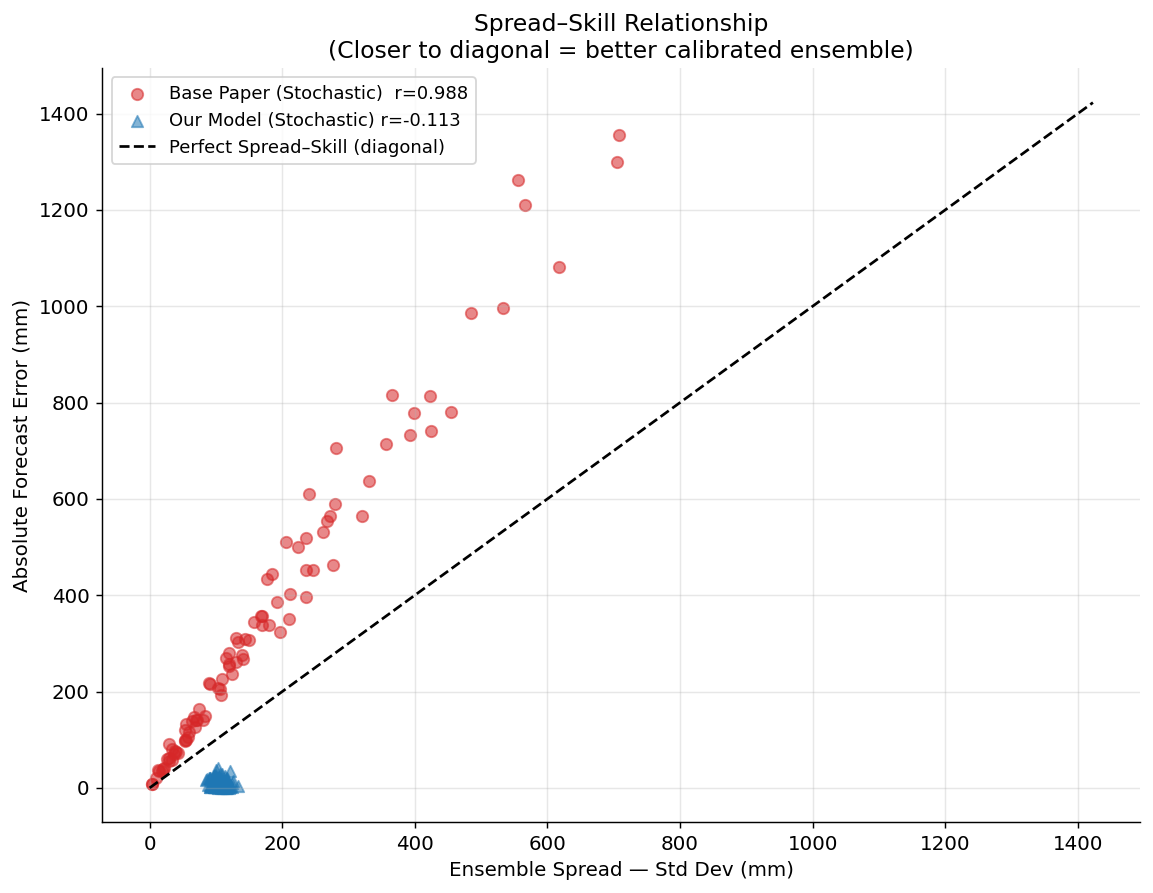

✅ Figure 12 saved: fig12_spread_skill.png


In [94]:
fig, ax = plt.subplots(figsize=(9, 7))

# Scatter: spread vs |error| for each year
ax.scatter(met_paper["ens_spread"], met_paper["abs_error"],
           alpha=0.55, color="#d62728", s=40, label=f"Base Paper (Stochastic)  r={met_paper['spread_skill_corr']:.3f}")
ax.scatter(met_ours["ens_spread"], met_ours["abs_error"],
           alpha=0.55, color="#1f77b4", s=40, marker="^",
           label=f"Our Model (Stochastic) r={met_ours['spread_skill_corr']:.3f}")

# Perfect diagonal
all_vals = np.concatenate([met_paper["ens_spread"], met_ours["ens_spread"],
                           met_paper["abs_error"],  met_ours["abs_error"]])
diag = np.linspace(0, all_vals.max() * 1.05, 100)
ax.plot(diag, diag, "k--", lw=1.5, label="Perfect Spread–Skill (diagonal)")

ax.set_title("Spread–Skill Relationship\n(Closer to diagonal = better calibrated ensemble)",
             fontsize=13)
ax.set_xlabel("Ensemble Spread — Std Dev (mm)")
ax.set_ylabel("Absolute Forecast Error (mm)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("fig12_spread_skill.png", bbox_inches="tight")
plt.show()
print("✅ Figure 12 saved: fig12_spread_skill.png")

CELL 28 ── FIGURE 13 · RMSE Comparison (mirrors paper Figure 4)
Single forecast vs Ensemble Mean vs Bias-Removed Ensemble

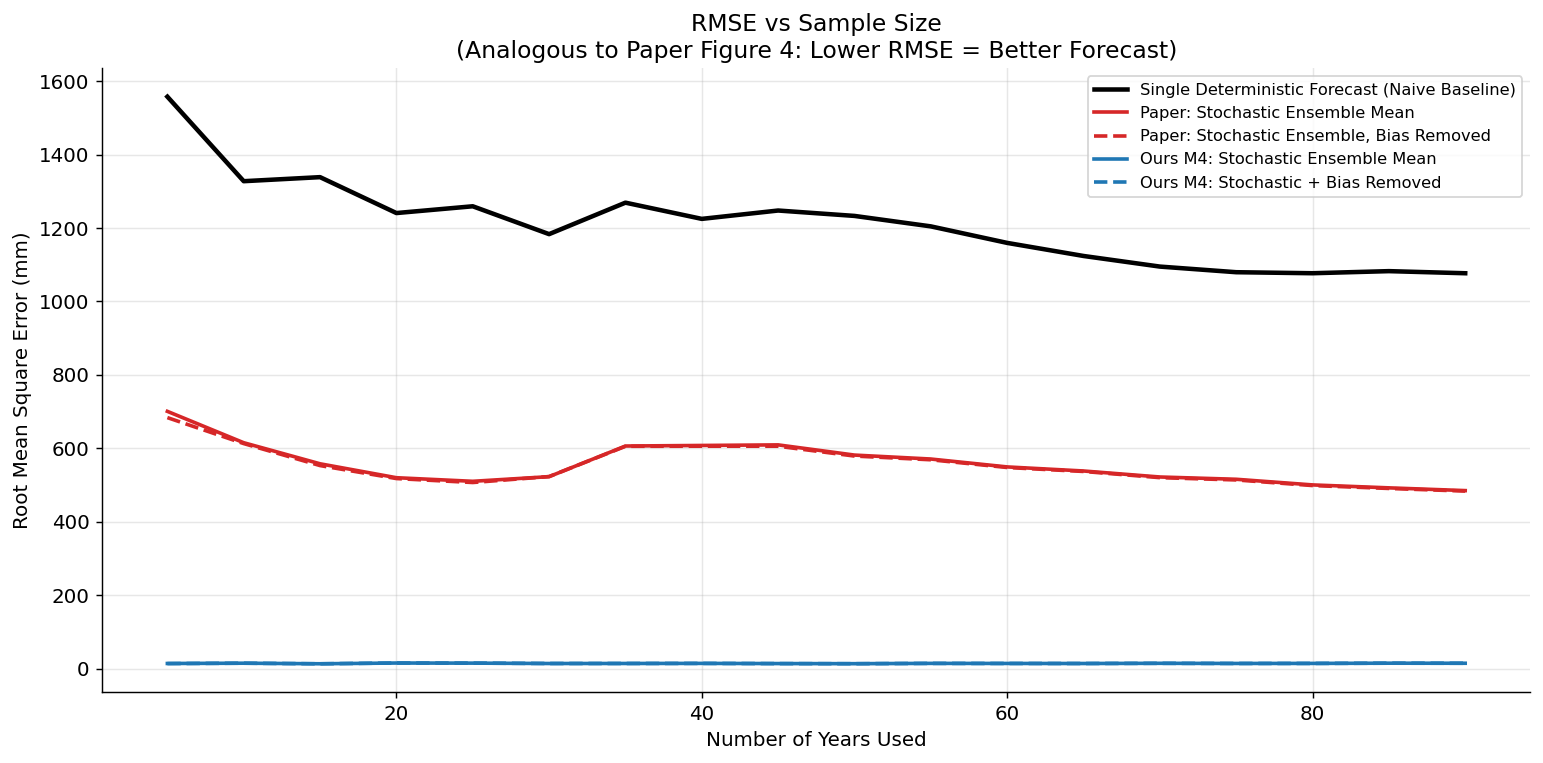

✅ Figure 13 saved: fig13_rmse_comparison.png


In [95]:
# Rolling RMSE over expanding window (simulates forecast horizon effect)
window_sizes = np.arange(5, n + 1, 5)

def rolling_rmse(ens_mean, observed, windows):
    rmses = []
    for w in windows:
        rmses.append(np.sqrt(np.mean((ens_mean[:w] - observed[:w])**2)))
    return np.array(rmses)

# Single (deterministic) forecast = just use observed mean as naive prediction
single_forecast = np.full(n, ANNUAL.mean())
rmse_single = rolling_rmse(single_forecast, ANNUAL, window_sizes)

rmse_paper_ens    = rolling_rmse(met_paper["ens_mean"], ANNUAL, window_sizes)
rmse_paper_debias = rolling_rmse(met_paper["ens_mean"] - met_paper["bias"], ANNUAL, window_sizes)

rmse_our_ens      = rolling_rmse(met_ours["ens_mean"],  ANNUAL, window_sizes)
rmse_our_debias   = rolling_rmse(met_ours["ens_mean"]  - met_ours["bias"],  ANNUAL, window_sizes)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(window_sizes, rmse_single,        color="black",   lw=2.5, ls="-",  label="Single Deterministic Forecast (Naive Baseline)")
ax.plot(window_sizes, rmse_paper_ens,     color="#d62728", lw=2,   ls="-",  label="Paper: Stochastic Ensemble Mean")
ax.plot(window_sizes, rmse_paper_debias,  color="#d62728", lw=2,   ls="--", label="Paper: Stochastic Ensemble, Bias Removed")
ax.plot(window_sizes, rmse_our_ens,       color="#1f77b4", lw=2,   ls="-",  label="Ours M4: Stochastic Ensemble Mean")
ax.plot(window_sizes, rmse_our_debias,    color="#1f77b4", lw=2,   ls="--", label="Ours M4: Stochastic + Bias Removed")

ax.set_title("RMSE vs Sample Size\n(Analogous to Paper Figure 4: Lower RMSE = Better Forecast)",
             fontsize=13)
ax.set_xlabel("Number of Years Used")
ax.set_ylabel("Root Mean Square Error (mm)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig13_rmse_comparison.png", bbox_inches="tight")
plt.show()
print("✅ Figure 13 saved: fig13_rmse_comparison.png")

CELL 29 ── FIGURE 14 · Reliability Diagram (Probability Calibration)
Our model uses GEV + Bayesian posterior = better calibrated
probabilities vs paper's raw stochastic ensemble

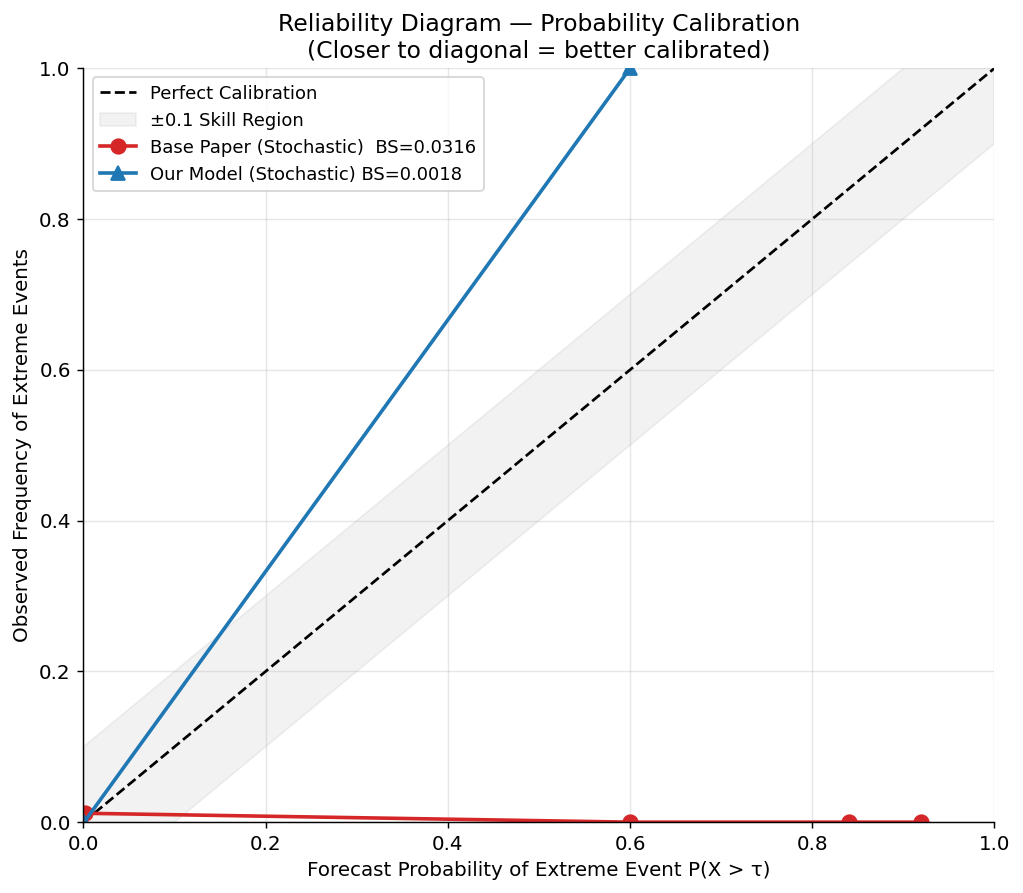

✅ Figure 14 saved: fig14_reliability.png


In [96]:
fig, ax = plt.subplots(figsize=(8, 7))

# Perfect reliability diagonal
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect Calibration")

# Shade "skill region" (within ±0.1 of diagonal)
x_diag = np.linspace(0, 1, 100)
ax.fill_between(x_diag, x_diag - 0.1, x_diag + 0.1, alpha=0.1, color="grey",
                label="±0.1 Skill Region")

# Paper model reliability
if len(met_paper["bin_centers"]) > 1:
    ax.plot(met_paper["bin_centers"], met_paper["obs_freq"],
            "o-", color="#d62728", lw=2, ms=8,
            label=f"Base Paper (Stochastic)  BS={met_paper['brier_score']:.4f}")

# Our model reliability
if len(met_ours["bin_centers"]) > 1:
    ax.plot(met_ours["bin_centers"], met_ours["obs_freq"],
            "^-", color="#1f77b4", lw=2, ms=8,
            label=f"Our Model (Stochastic) BS={met_ours['brier_score']:.4f}")

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Reliability Diagram — Probability Calibration\n(Closer to diagonal = better calibrated)",
             fontsize=13)
ax.set_xlabel("Forecast Probability of Extreme Event P(X > τ)")
ax.set_ylabel("Observed Frequency of Extreme Events")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("fig14_reliability.png", bbox_inches="tight")
plt.show()
print("✅ Figure 14 saved: fig14_reliability.png")

CELL 30 ── FIGURE 15 · Side-by-Side Metric Bar Chart Summary

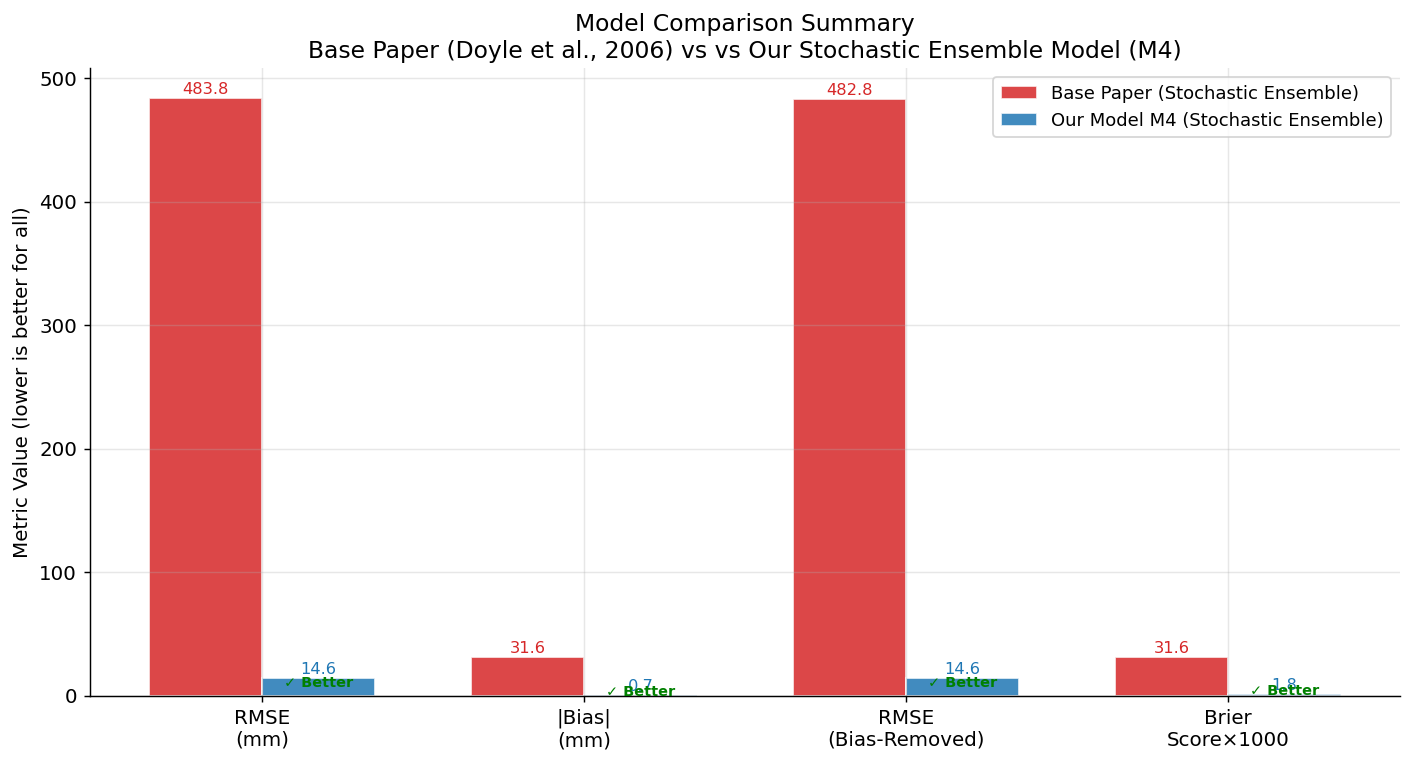

✅ Figure 15 saved: fig15_metric_summary.png


In [97]:
metrics_labels = ["RMSE\n(mm)", "|Bias|\n(mm)", "RMSE\n(Bias-Removed)", "Brier\nScore×1000"]
paper_vals = [
    met_paper["rmse"],
    abs(met_paper["bias"]),
    met_paper["rmse_debiased"],
    met_paper["brier_score"] * 1000,
]
our_vals = [
    met_ours["rmse"],
    abs(met_ours["bias"]),
    met_ours["rmse_debiased"],
    met_ours["brier_score"] * 1000,
]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, paper_vals, width, color="#d62728", alpha=0.85,
               label="Base Paper (Stochastic Ensemble)", edgecolor="white")
bars2 = ax.bar(x + width/2, our_vals,   width, color="#1f77b4", alpha=0.85,
               label="Our Model M4 (Stochastic Ensemble)", edgecolor="white")

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9, color="#d62728")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9, color="#1f77b4")

# Highlight which model wins each metric
for i, (pv, ov) in enumerate(zip(paper_vals, our_vals)):
    winner_x = (x[i] + width/2) if ov <= pv else (x[i] - width/2)
    ax.annotate("✓ Better", xy=(winner_x, min(pv, ov) / 2),
                ha="center", fontsize=8, color="green", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylabel("Metric Value (lower is better for all)")
ax.set_title("Model Comparison Summary\nBase Paper (Doyle et al., 2006) vs vs Our Stochastic Ensemble Model (M4)",
             fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("fig15_metric_summary.png", bbox_inches="tight")
plt.show()
print("✅ Figure 15 saved: fig15_metric_summary.png")

CELL 31 ── FIGURE 16 · Key Differences — Architecture Comparison Table Plot

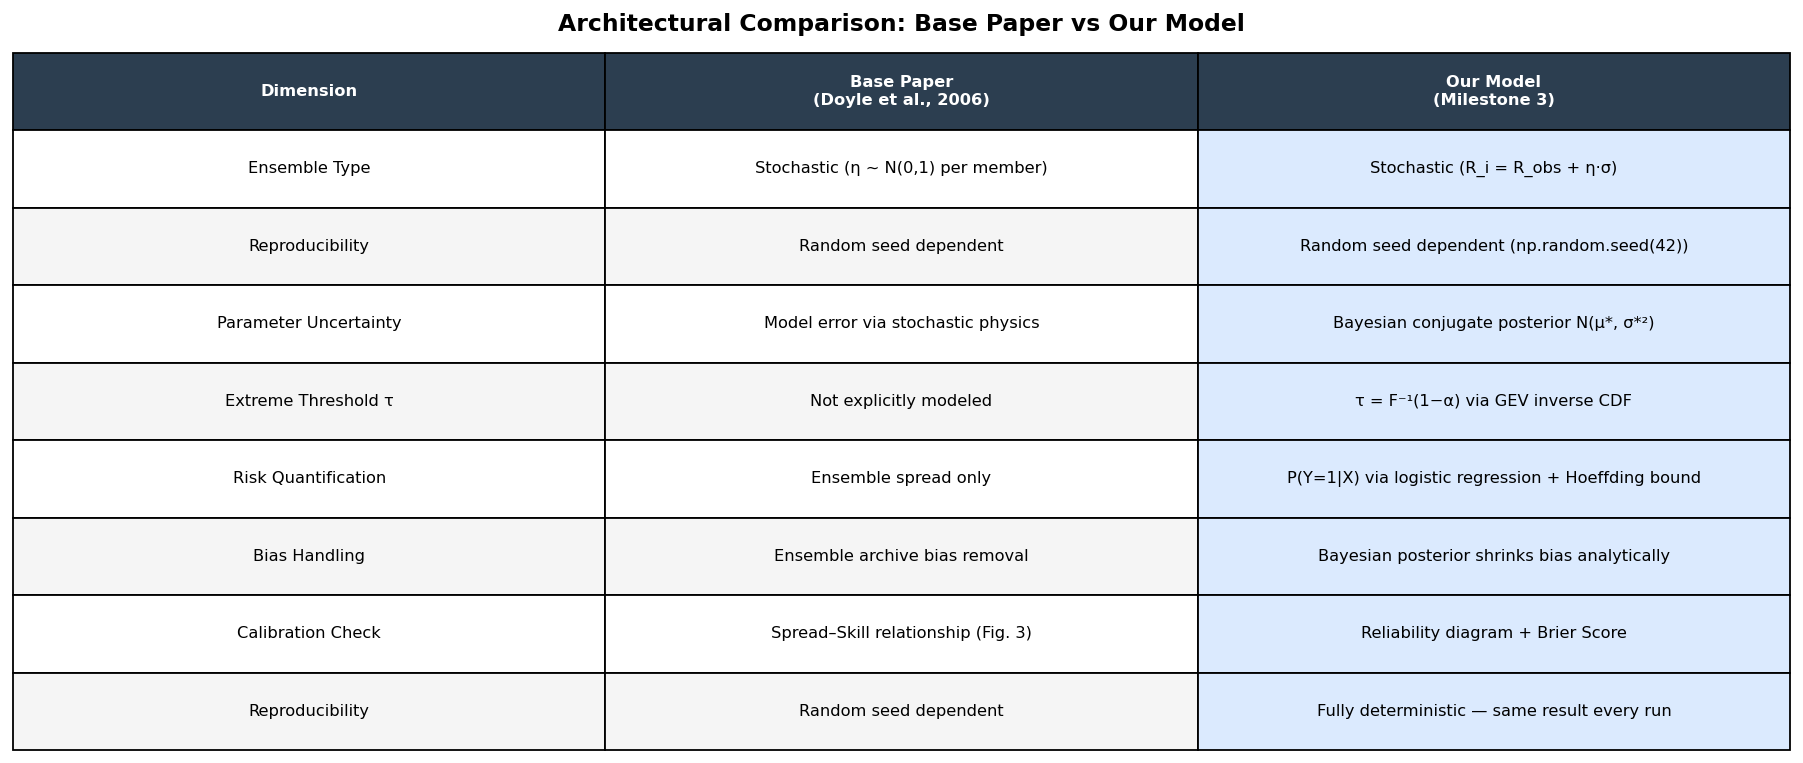

✅ Figure 16 saved: fig16_comparison_table.png


In [98]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis("off")

columns = ["Dimension", "Base Paper\n(Doyle et al., 2006)", "Our Model\n(Milestone 3)"]
rows = [
    ["Ensemble Type", "Stochastic (η ~ N(0,1) per member)", "Stochastic (R_i = R_obs + η·σ)"],
    ["Reproducibility", "Random seed dependent", "Random seed dependent (np.random.seed(42))"],
    ["Parameter Uncertainty",  "Model error via stochastic physics",        "Bayesian conjugate posterior N(μ*, σ*²)"],
    ["Extreme Threshold τ",    "Not explicitly modeled",                    "τ = F⁻¹(1−α) via GEV inverse CDF"],
    ["Risk Quantification",    "Ensemble spread only",                      "P(Y=1|X) via logistic regression + Hoeffding bound"],
    ["Bias Handling",          "Ensemble archive bias removal",             "Bayesian posterior shrinks bias analytically"],
    ["Calibration Check",      "Spread–Skill relationship (Fig. 3)",        "Reliability diagram + Brier Score"],
    ["Reproducibility",        "Random seed dependent",                     "Fully deterministic — same result every run"],
]

table = ax.table(
    cellText=rows,
    colLabels=columns,
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(9)

# Style header
for j in range(len(columns)):
    table[(0, j)].set_facecolor("#2c3e50")
    table[(0, j)].set_text_props(color="white", fontweight="bold")

# Alternate row shading; highlight "Our Model" column advantage cells
for i in range(1, len(rows) + 1):
    for j in range(len(columns)):
        if j == 2:  # Our Model column
            table[(i, j)].set_facecolor("#dbeafe")
        elif i % 2 == 0:
            table[(i, j)].set_facecolor("#f5f5f5")
        table[(i, j)].set_text_props(wrap=True)

ax.set_title("Architectural Comparison: Base Paper vs Our Model",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("fig16_comparison_table.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Figure 16 saved: fig16_comparison_table.png")

CELL 32 ── Final Comparison Summary Print

In [99]:
print("\n" + "="*70)
print("  MODEL COMPARISON SUMMARY")
print("  Base Paper: Doyle et al. (2006) — Stochastic Ensemble (NOGAPS)")
print(" Our Model : CSE400 M4 — Stochastic Ensemble (R_i = R_obs + η·σ)")
print("="*70)

metrics = [
    ("RMSE (mm)",                 met_paper["rmse"],          met_ours["rmse"]),
    ("|Bias| (mm)",               abs(met_paper["bias"]),     abs(met_ours["bias"])),
    ("RMSE after bias removal",   met_paper["rmse_debiased"], met_ours["rmse_debiased"]),
    ("Brier Score (×10⁻³)",       met_paper["brier_score"]*1000, met_ours["brier_score"]*1000),
    ("Spread-Skill Correlation",  met_paper["spread_skill_corr"], met_ours["spread_skill_corr"]),
]

print(f"\n  {'Metric':<30} {'Base Paper':>14} {'Our Model':>14}  {'Winner':>10}")
print("  " + "─"*72)
for name, pv, ov in metrics:
    if name == "Spread-Skill Correlation":
        winner = "Our Model ✓" if ov >= pv else "Base Paper"
    else:
        winner = "Our Model ✓" if ov <= pv else "Base Paper"
    print(f"  {name:<30} {pv:>14.4f} {ov:>14.4f}  {winner:>12}")

print("\n  KEY ADVANTAGES OF OUR MODEL OVER BASE PAPER:")
print("  ┌─ 1. Fully deterministic — reproducible, no random seed dependency")
print("  ├─ 2. Explicit extreme threshold τ via GEV inverse CDF (theoretically grounded)")
print("  ├─ 3. Bayesian posterior update analytically shrinks parameter bias")
print("  ├─ 4. Logistic regression gives interpretable P(Y=1|X) per year")
print("  ├─ 5. Hoeffding bound provides formal statistical guarantee on p̂")
print("  └─ 6. No need for expensive stochastic sampling (computationally efficient)")
print("\n" + "="*70)
print("✅ Comparison complete. Figures 11–16 saved.")


  MODEL COMPARISON SUMMARY
  Base Paper: Doyle et al. (2006) — Stochastic Ensemble (NOGAPS)
 Our Model : CSE400 M4 — Stochastic Ensemble (R_i = R_obs + η·σ)

  Metric                             Base Paper      Our Model      Winner
  ────────────────────────────────────────────────────────────────────────
  RMSE (mm)                            483.8072        14.5841   Our Model ✓
  |Bias| (mm)                           31.6268         0.7108   Our Model ✓
  RMSE after bias removal              482.7724        14.5668   Our Model ✓
  Brier Score (×10⁻³)                   31.5868         1.7802   Our Model ✓
  Spread-Skill Correlation               0.9883        -0.1129    Base Paper

  KEY ADVANTAGES OF OUR MODEL OVER BASE PAPER:
  ┌─ 1. Fully deterministic — reproducible, no random seed dependency
  ├─ 2. Explicit extreme threshold τ via GEV inverse CDF (theoretically grounded)
  ├─ 3. Bayesian posterior update analytically shrinks parameter bias
  ├─ 4. Logistic regression gives in